In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Huh1_glycolysis

In [2]:
file_path = 'Glycolysis_Pathway_activity_for_Huh1_cells.xlsx'
df = pd.read_excel(file_path, sheet_name='glycolysis activity')

In [3]:
df = df.set_index('Cell_number')
df

,HXK,GPI,PFK,ALD,TPI1,GAPDH,PGK,PGAM,ENO,PYK,Enzyme inactive number,Enzyme active number,Unnamed: 13,Enzyme active number.1,Cell number (Huh1)
Cell_number,,,,,,,,,,,,,,,
Cell1,0,1,0,8,20,43,3,7,18,3,2,8,136.0,4.0,4.0
Cell2,0,5,0,19,53,107,10,5,46,21,2,8,NaN,5.0,8.0
Cell3,2,6,3,11,14,103,3,10,16,26,0,10,NaN,6.0,29.0
Cell4,1,1,3,37,69,179,27,27,60,12,0,10,NaN,7.0,111.0
Cell5,0,2,0,7,12,30,3,6,7,4,2,8,NaN,8.0,274.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell890,2,2,0,2,16,27,4,2,7,8,1,9,NaN,NaN,NaN
Cell891,3,2,2,13,12,52,0,2,18,10,1,9,NaN,NaN,NaN
Cell892,2,3,2,8,17,66,2,5,16,10,0,10,NaN,NaN,NaN


In [4]:
cumulative_counts = df.eq(0).sum()
cumulative_counts

HXK                       548
GPI                       187
PFK                       471
ALD                         9
TPI1                        1
GAPDH                       0
PGK                        94
PGAM                       62
ENO                         5
PYK                        16
Enzyme inactive number    136
Enzyme active number        0
Unnamed: 13                 0
Enzyme active number.1      0
Cell number (Huh1)          0
dtype: int64

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


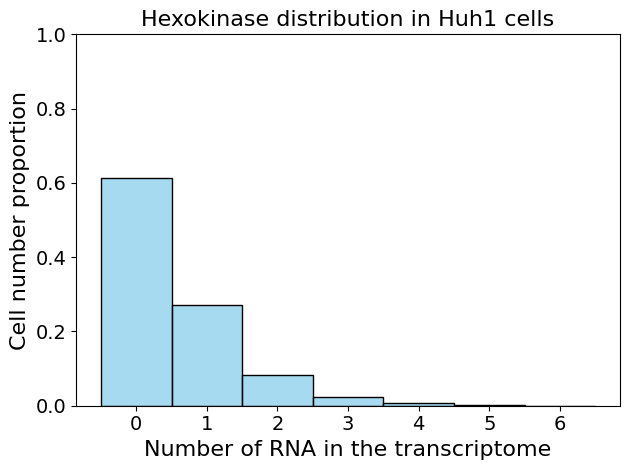

In [29]:
## For HXK distribution
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['HXK'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
             kde=False, color='skyblue',stat='probability')
plt.title('Hexokinase distribution in Huh1 cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('HXK_distribution/Hexokinase in Huh1',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


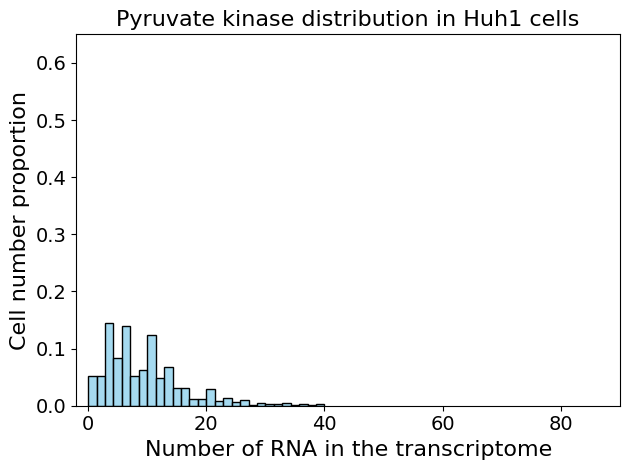

In [5]:
## For PYK distribution
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], 
             kde=False, color='skyblue',stat='probability')
plt.title('Pyruvate kinase distribution in Huh1 cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.65)
plt.xlim(-2, 90)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()
# plt.savefig('PYK_distribution/Pyruvate kinase in Huh1',dpi=300)

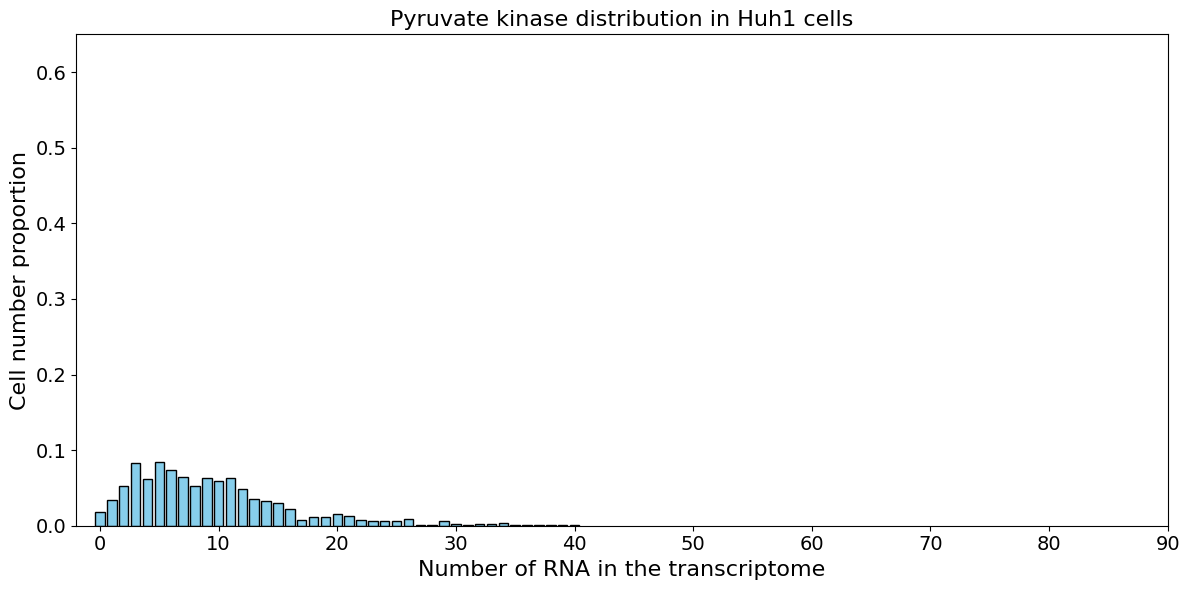

In [11]:
# 1. 精确计算每个表达量的比例
prob_df = df['PYK'].value_counts(normalize=True).reset_index()
prob_df.columns = ['PYK_count', 'proportion']

# 2. 绘图（改用 plt.bar，可以完美控制数值型 X 轴）
plt.figure(figsize=(12, 6))

# width=0.8 可以让柱子之间有明显的间隙，不粘在一起
plt.bar(prob_df['PYK_count'], prob_df['proportion'], color='skyblue', width=0.8,edgecolor='black')

# 3. 设置 X 轴的范围和刻度
# 强制只在 0, 10, 20 ... 90 的位置显示刻度线和文字
tick_positions = np.arange(0, 91, 10) 
plt.xticks(tick_positions, labels=tick_positions, fontsize=14)
plt.yticks(fontsize=14)

# 限制 X 轴显示范围在 -2 到 90 之间
plt.xlim(-2, 90)
plt.ylim(0, 0.65)

# 4. 隐藏中间不需要的那些小小刻度线
# 这一步能确保界面干净，只在 0, 10...90 的地方有刻度小短线
ax = plt.gca()
ax.xaxis.set_major_locator(plt.FixedLocator(tick_positions))

# 5. 基础美化
plt.title('Pyruvate kinase distribution in Huh1 cells', fontsize=16)
plt.xlabel('Number of RNA in the transcriptome', fontsize=16)
plt.ylabel('Cell number proportion', fontsize=16)

plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Huh1(2)',dpi=300)

In [6]:
import pandas as pd

# 1. 计算每个数值出现的频数并转化为比例（概率）
# normalize=True 会直接计算比例，sort=False 保证按数值大小排序（可选）
pyk_probs = df['PYK'].value_counts(normalize=True).sort_index().reset_index()

# 2. 重命名列名，让 Excel 表格更易读
pyk_probs.columns = ['PYK_Value', 'Probability']

# 3. 输出成 Excel 文件
output_path = 'PYK_distribution_probabilities.xlsx'
pyk_probs.to_excel(output_path, index=False)

print(f"概率分布已成功保存至: {output_path}")

# 如果你想在控制台顺便看一眼前几行
print(pyk_probs.head())

概率分布已成功保存至: PYK_distribution_probabilities.xlsx
   PYK_Value  Probability
0          0     0.017897
1          1     0.033557
2          2     0.052573
3          3     0.082774
4          4     0.061521


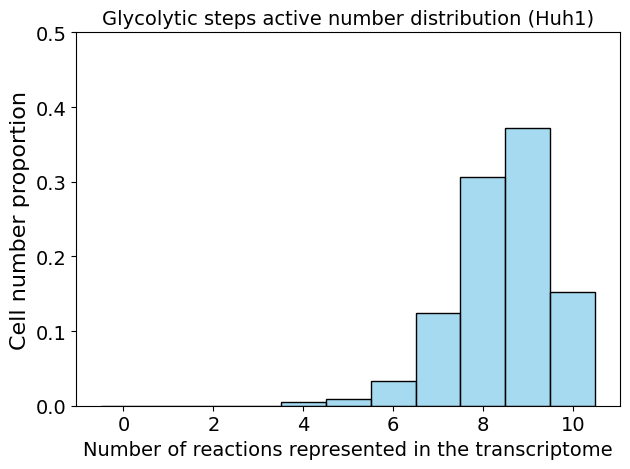

In [10]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], 
             kde=False, color='skyblue',stat='density')
plt.title('Glycolytic steps active number distribution (Huh1)',fontsize=14)
plt.xlabel('Number of reactions represented in the transcriptome',fontsize=14)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.5)
# plt.show()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Huh1)',dpi=300)

In [20]:
# Calculate the count of 0 values exclusive to each column
exclusive_counts = (df.eq(0) & (df.sum(axis=1) == df['HEX1(total)'])).sum()
exclusive_counts

Cell1         0
Cell10        0
Cell100       0
Cell101       0
Cell102       0
             ..
PFK(total)    0
PGK(total)    0
PGM(total)    0
PYK(total)    0
TPI1          0
Length: 904, dtype: int64

In [37]:
row_counts = df.eq(0).sum(axis=1)
row_counts

Cell_number
Cell1      2
Cell2      2
Cell3      0
Cell4      0
Cell5      2
          ..
Cell890    1
Cell891    1
Cell892    0
Cell893    2
Cell894    2
Length: 894, dtype: int64

In [47]:
# Count the number of rows with no 0 values
no_zero_rows = df[df.eq(0).sum(axis=1) == 0]

# Get the count of such rows
count_no_zero_rows = len(no_zero_rows)

print("Number of Rows with No 0 Values:", count_no_zero_rows)

Number of Rows with No 0 Values: 136


# Huh7 cell lines

## Huh7_Glycolysis

In [12]:
file_path = 'Glycolysis_Pathway_activity_for_Huh7_cells.xlsx'
df = pd.read_excel(file_path, sheet_name='Huh7_glycolysis')

In [13]:
df = df.set_index('Cell_number')
df

,HXK,GPI,PFK,ALD,TPI1,GAPDH,PGK,PGAM,ENO,PYK,Enzyme inactive number,Enzyme active number,Unnamed: 13,Enzyme active number.1,Cell number (Huh1)
Cell_number,,,,,,,,,,,,,,,
Cell895,0,1,1,17,41,116,2,7,13,15,1,9,0.0,3.0,1.0
Cell896,0,0,0,6,36,56,1,9,22,13,3,7,NaN,4.0,1.0
Cell897,0,0,0,11,18,73,4,8,14,10,3,7,NaN,5.0,24.0
Cell898,0,1,0,4,10,5,1,4,6,3,2,8,NaN,6.0,137.0
Cell899,0,0,1,5,13,37,2,2,11,8,2,8,NaN,7.0,552.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell2972,0,0,1,21,76,142,4,10,25,18,2,8,NaN,NaN,NaN
Cell2973,0,2,6,63,69,187,16,25,60,51,1,9,NaN,NaN,NaN
Cell2974,0,0,1,40,50,139,19,30,54,36,2,8,NaN,NaN,NaN


/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


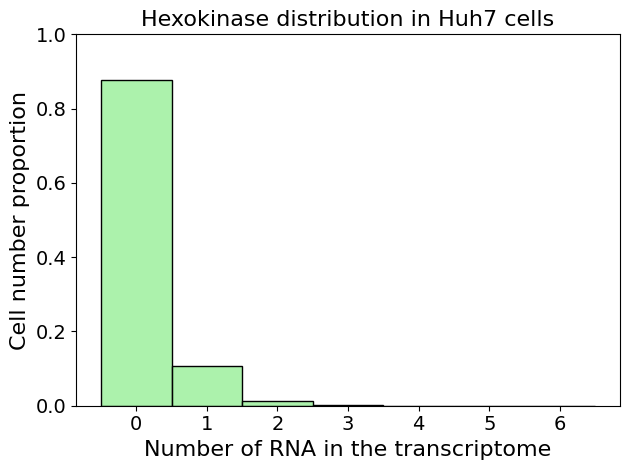

In [33]:
## For HXK distribution
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['HXK'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
             kde=False, color='lightgreen',stat='probability')
plt.title('Hexokinase distribution in Huh7 cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('HXK_distribution/Hexokinase in Huh7',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


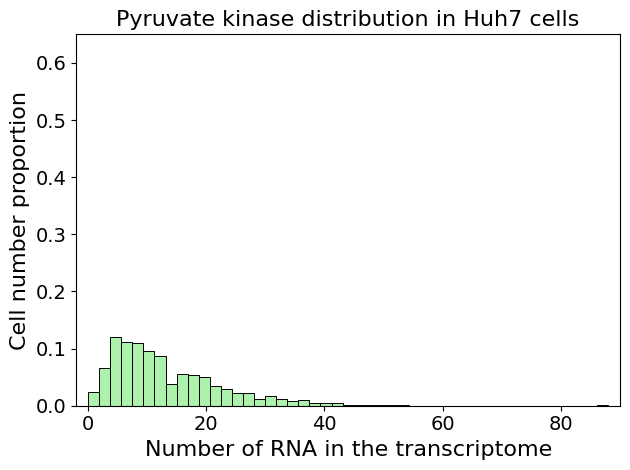

In [34]:
## For PYK distribution
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], 
             kde=False, color='lightgreen',stat='probability')
plt.title('Pyruvate kinase distribution in Huh7 cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.65)
plt.xlim(-2, 90)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Huh7',dpi=300)

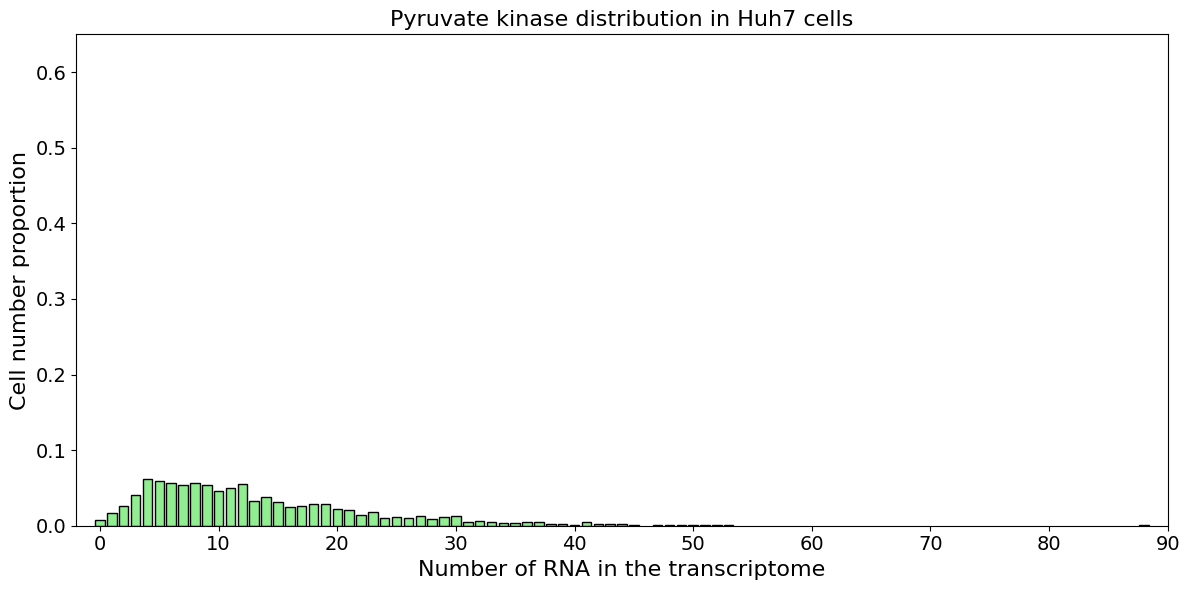

In [14]:
# 1. 精确计算每个表达量的比例
prob_df = df['PYK'].value_counts(normalize=True).reset_index()
prob_df.columns = ['PYK_count', 'proportion']

# 2. 绘图（改用 plt.bar，可以完美控制数值型 X 轴）
plt.figure(figsize=(12, 6))

# width=0.8 可以让柱子之间有明显的间隙，不粘在一起
plt.bar(prob_df['PYK_count'], prob_df['proportion'], color='lightgreen', width=0.8,edgecolor='black')

# 3. 设置 X 轴的范围和刻度
# 强制只在 0, 10, 20 ... 90 的位置显示刻度线和文字
tick_positions = np.arange(0, 91, 10) 
plt.xticks(tick_positions, labels=tick_positions, fontsize=14)
plt.yticks(fontsize=14)

# 限制 X 轴显示范围在 -2 到 90 之间
plt.xlim(-2, 90)
plt.ylim(0, 0.65)

# 4. 隐藏中间不需要的那些小小刻度线
# 这一步能确保界面干净，只在 0, 10...90 的地方有刻度小短线
ax = plt.gca()
ax.xaxis.set_major_locator(plt.FixedLocator(tick_positions))

# 5. 基础美化
plt.title('Pyruvate kinase distribution in Huh7 cells', fontsize=16)
plt.xlabel('Number of RNA in the transcriptome', fontsize=16)
plt.ylabel('Cell number proportion', fontsize=16)

plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Huh7(2)',dpi=300)

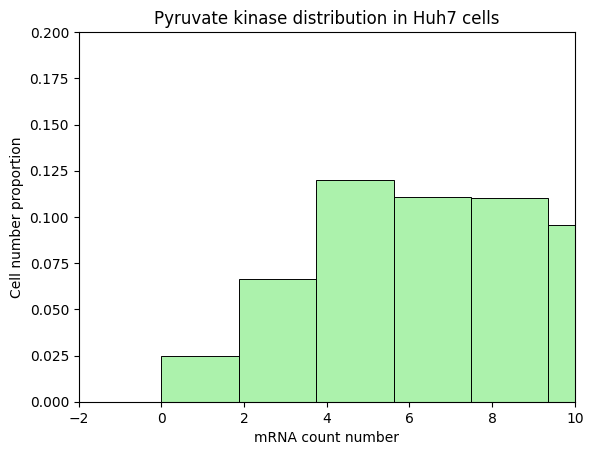

In [82]:
## For PYK distribution
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], 
             kde=False, color='lightgreen',stat='probability')
plt.title('Pyruvate kinase distribution in Huh7 cells')
plt.xlabel('mRNA count number')
plt.ylabel('Cell number proportion')
plt.ylim(0, 0.2)
plt.xlim(-2, 10)
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Huh7_2',dpi=300)

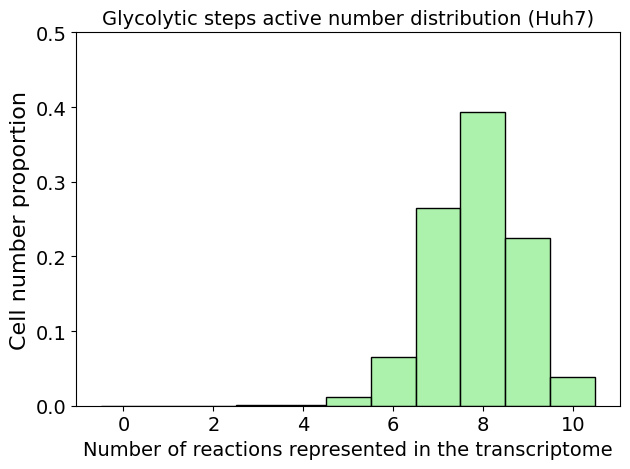

In [15]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], 
             kde=False, color='lightgreen',stat='density')
plt.title('Glycolytic steps active number distribution (Huh7)',fontsize=14)
plt.xlabel('Number of reactions represented in the transcriptome',fontsize=14)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.5)
# plt.show()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Huh7)',dpi=300)

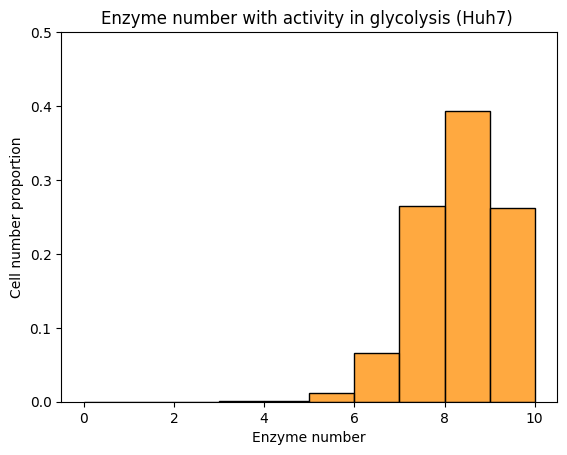

In [95]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 
             kde=False, color='lightgreen',stat='density')
plt.title('Enzyme number with activity in glycolysis (Huh7) ')
plt.xlabel('Enzyme number')
plt.ylabel('Cell number proportion')
plt.ylim(0, 0.5)
plt.show()
# plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Huh7)',dpi=300)

In [79]:
cumulative_counts = df.eq(0).sum()
cumulative_counts

HXK                       1827
GPI                       1279
PFK                        930
ALD                         15
TPI1                         2
GAPDH                        0
PGK                        289
PGAM                        81
ENO                          5
PYK                         16
Enzyme inactive number      80
Enzyme active number         0
Unnamed: 13                  1
Enzyme active number.1       0
Cell number (Huh1)           0
dtype: int64

In [80]:
# Count the number of rows with no 0 values
no_zero_rows = df[df.eq(0).sum(axis=1) == 0]

# Get the count of such rows
count_no_zero_rows = len(no_zero_rows)

print("Number of Rows with No 0 Values:", count_no_zero_rows)

Number of Rows with No 0 Values: 0


# Patient cell lines

## Patient_glycolysis

In [15]:
file_path = 'Glycolysis_Pathway_activity_for_Patient_cells.xlsx'
df = pd.read_excel(file_path, sheet_name='Patient_glycolysis')

In [16]:
df = df.set_index('Cell_number')
df

,HXK,GPI,PFK,ALD,TPI1,GAPDH,PGK,PGAM,ENO,PYK,Enzyme inactive number,Enzyme active number,Unnamed: 13,Enzyme active number.1,Cell number (Patient)
Cell_number,,,,,,,,,,,,,,,
Cell2976,0,0,1,4,1,4,2,0,2,1,3,7,5.0,0.0,42.0
Cell2977,0,0,0,0,0,2,0,0,0,1,8,2,NaN,1.0,80.0
Cell2978,0,0,0,4,9,17,2,0,2,10,4,6,NaN,2.0,85.0
Cell2979,0,0,0,0,0,4,0,0,0,0,9,1,NaN,3.0,91.0
Cell2980,0,0,0,0,1,1,0,0,0,0,8,2,NaN,4.0,106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell3644,0,0,1,2,2,2,0,0,0,0,6,4,NaN,NaN,NaN
Cell3645,0,0,0,0,0,2,0,0,0,0,9,1,NaN,NaN,NaN
Cell3646,0,0,0,0,0,0,1,0,0,0,9,1,NaN,NaN,NaN


/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


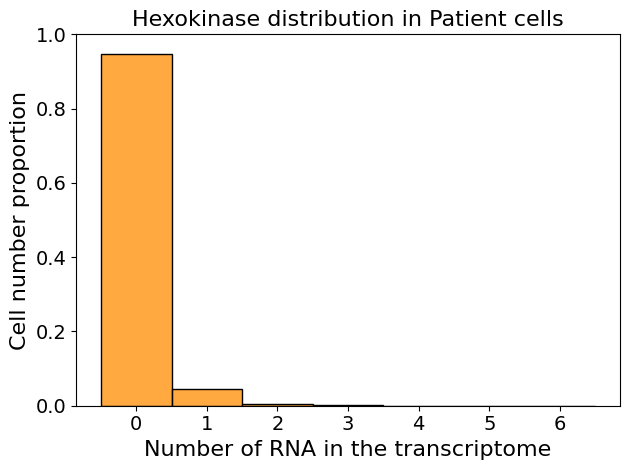

In [37]:
## For HXK
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['HXK'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
             kde=False, color='darkorange',stat='probability')
plt.title('Hexokinase distribution in Patient cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('HXK_distribution/Hexokinase in Patient cells',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


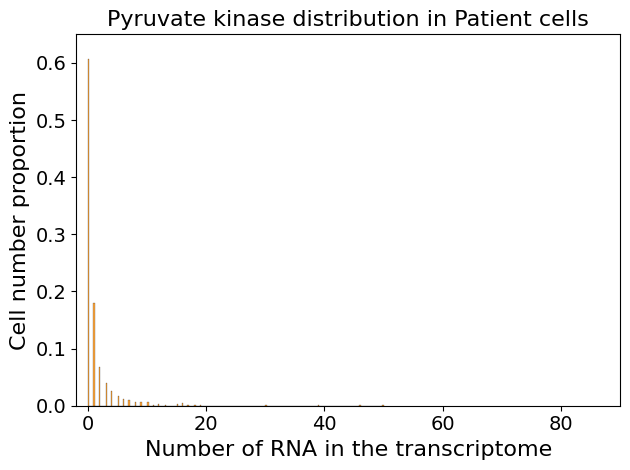

In [38]:
## For PYK
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], kde=False, color='darkorange',stat='probability')
plt.title('Pyruvate kinase distribution in Patient cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.65)
plt.xlim(-2, 90)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Patient cells_1',dpi=300)

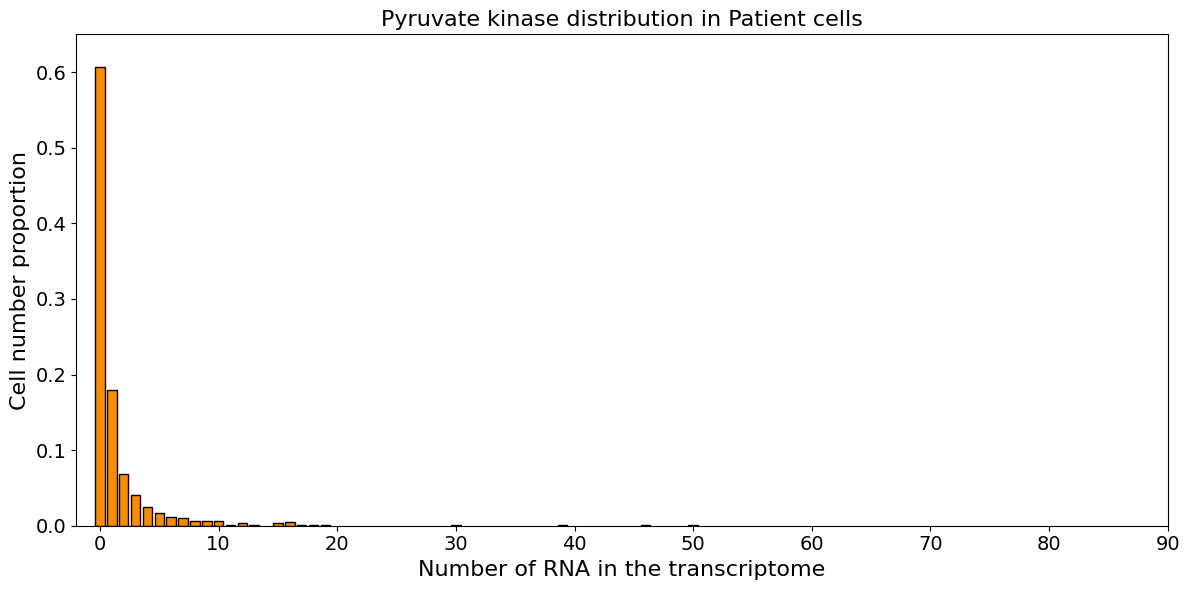

In [17]:
# 1. 精确计算每个表达量的比例
prob_df = df['PYK'].value_counts(normalize=True).reset_index()
prob_df.columns = ['PYK_count', 'proportion']

# 2. 绘图（改用 plt.bar，可以完美控制数值型 X 轴）
plt.figure(figsize=(12, 6))

# width=0.8 可以让柱子之间有明显的间隙，不粘在一起
plt.bar(prob_df['PYK_count'], prob_df['proportion'], color='darkorange', width=0.8,edgecolor='black')

# 3. 设置 X 轴的范围和刻度
# 强制只在 0, 10, 20 ... 90 的位置显示刻度线和文字
tick_positions = np.arange(0, 91, 10) 
plt.xticks(tick_positions, labels=tick_positions, fontsize=14)
plt.yticks(fontsize=14)

# 限制 X 轴显示范围在 -2 到 90 之间
plt.xlim(-2, 90)
plt.ylim(0, 0.65)

# 4. 隐藏中间不需要的那些小小刻度线
# 这一步能确保界面干净，只在 0, 10...90 的地方有刻度小短线
ax = plt.gca()
ax.xaxis.set_major_locator(plt.FixedLocator(tick_positions))

# 5. 基础美化
plt.title('Pyruvate kinase distribution in Patient cells', fontsize=16)
plt.xlabel('Number of RNA in the transcriptome', fontsize=16)
plt.ylabel('Cell number proportion', fontsize=16)

plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Patient(2)',dpi=300)

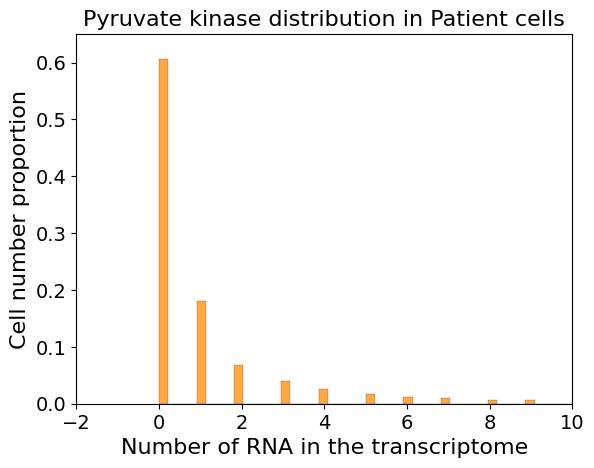

In [20]:
## For PYK
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], kde=False, color='darkorange',stat='probability')
plt.title('Pyruvate kinase distribution in Patient cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.65)
plt.xlim(-2, 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Patient cells_2',dpi=300)

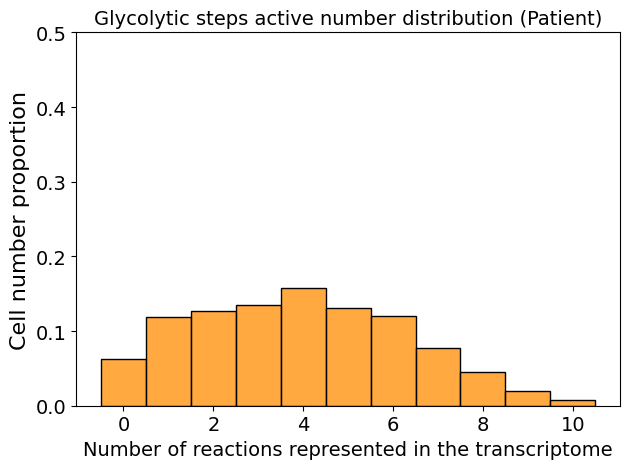

In [21]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], 
             kde=False, color='darkorange',stat='density')
plt.title('Glycolytic steps active number distribution (Patient)',fontsize=14)
plt.xlabel('Number of reactions represented in the transcriptome',fontsize=14)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.5)
# plt.show()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Patient)',dpi=300)

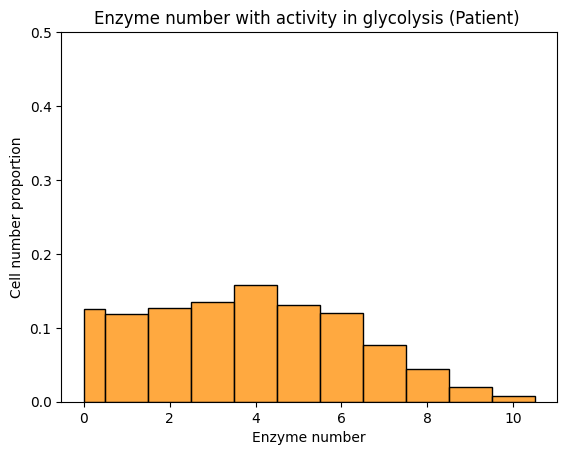

In [99]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], 
             kde=False, color='darkorange',stat='density')
plt.title('Enzyme number with activity in glycolysis (Patient) ')
plt.xlabel('Enzyme number')
plt.ylabel('Cell number proportion')
plt.ylim(0, 0.5)
plt.show()
# plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Patient)',dpi=300)

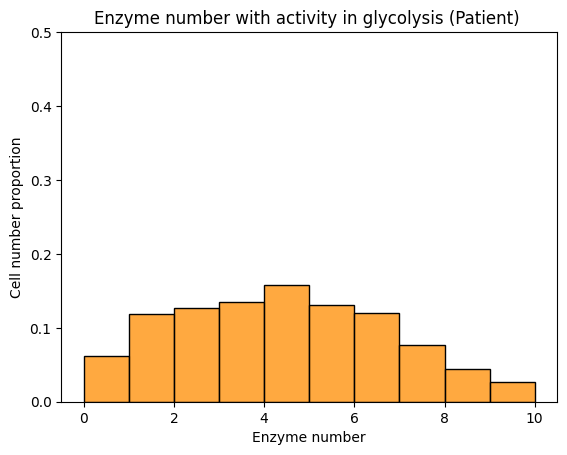

In [92]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 
             kde=False, color='darkorange',stat='density')
plt.title('Enzyme number with activity in glycolysis (Patient) ')
plt.xlabel('Enzyme number')
plt.ylabel('Cell number proportion')
plt.ylim(0, 0.5)
plt.show()
# plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Patient)',dpi=300)

In [48]:
cumulative_counts = df.eq(0).sum()
cumulative_counts

HXK      637
GPI      598
PFK      557
ALD      324
TPI1     289
GAPDH     91
PGK      389
PGAM     462
ENO      331
PYK      408
dtype: int64

In [49]:
# Count the number of rows with no 0 values
no_zero_rows = df[df.eq(0).sum(axis=1) == 0]

# Get the count of such rows
count_no_zero_rows = len(no_zero_rows)

print("Number of Rows with No 0 Values:", count_no_zero_rows)

Number of Rows with No 0 Values: 5


# Healthy cells

In [18]:
file_path = 'Glycolysis_Pathway_activity_for_Healthy_cells.xlsx'
df = pd.read_excel(file_path, sheet_name='Healthy_glycolysis')

In [19]:
df = df.set_index('Cell_number')
df

,HXK,GPI,PFK,ALD,TPI1,GAPDH,PGK,PGAM,ENO,PYK,Enzyme inactive number,Enzyme active number,Unnamed: 13,Enzyme active number.1,Cell number (Huh1)
Cell_number,,,,,,,,,,,,,,,
Cell1,0,0,0,1,0,1,1,0,1,1,5,5,3.0,0.0,37.0
Cell2,1,0,0,5,5,8,2,1,0,3,3,7,NaN,1.0,154.0
Cell3,0,0,0,2,0,1,1,0,0,2,6,4,NaN,2.0,215.0
Cell4,0,0,0,1,1,6,1,0,1,2,4,6,NaN,3.0,351.0
Cell5,0,0,0,3,0,12,2,1,0,2,5,5,NaN,4.0,328.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell1859,0,0,0,1,1,1,0,0,1,0,6,4,NaN,NaN,NaN
Cell1860,0,0,0,1,1,2,0,0,0,3,6,4,NaN,NaN,NaN
Cell1861,0,1,0,1,1,2,2,1,0,0,4,6,NaN,NaN,NaN


/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


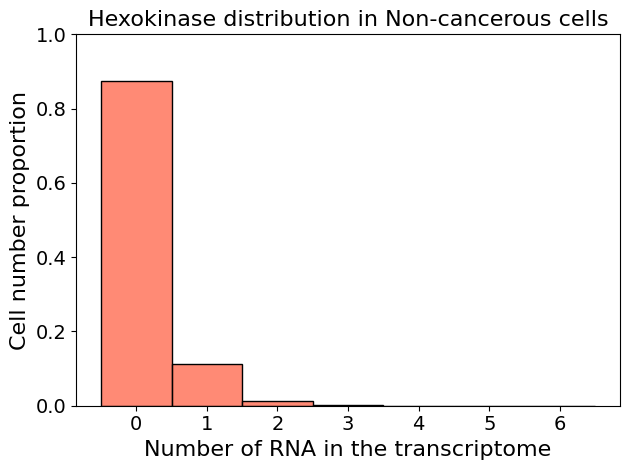

In [5]:
## For HXK
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['HXK'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
             kde=False, color='tomato',stat='probability')
plt.title('Hexokinase distribution in Non-cancerous cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.show()
plt.tight_layout()
plt.savefig('HXK_distribution/Hexokinase in Healthy cells',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


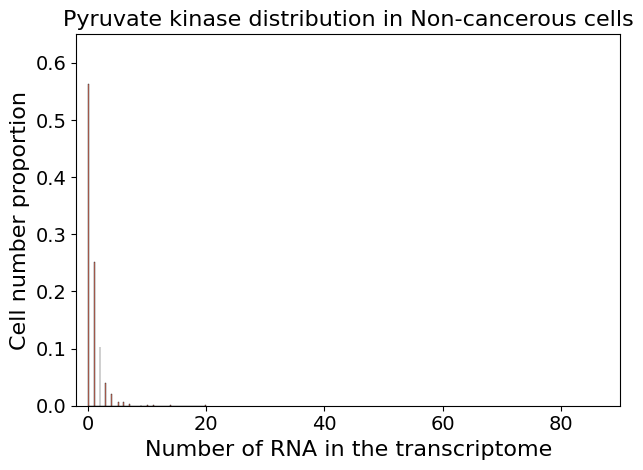

In [6]:
## For PYK
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], kde=False, color='tomato',stat='probability')
plt.title('Pyruvate kinase distribution in Non-cancerous cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.65)
plt.xlim(-2, 90)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Healthy cells',dpi=300)

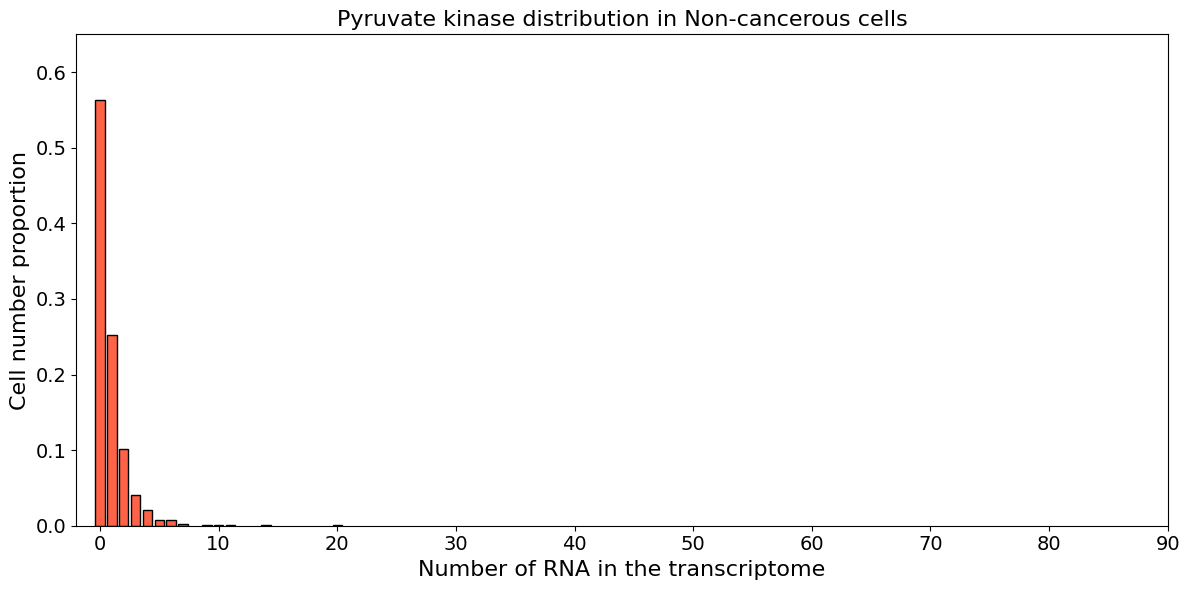

In [20]:
# 1. 精确计算每个表达量的比例
prob_df = df['PYK'].value_counts(normalize=True).reset_index()
prob_df.columns = ['PYK_count', 'proportion']

# 2. 绘图（改用 plt.bar，可以完美控制数值型 X 轴）
plt.figure(figsize=(12, 6))

# width=0.8 可以让柱子之间有明显的间隙，不粘在一起
plt.bar(prob_df['PYK_count'], prob_df['proportion'], color='tomato', width=0.8,edgecolor='black')

# 3. 设置 X 轴的范围和刻度
# 强制只在 0, 10, 20 ... 90 的位置显示刻度线和文字
tick_positions = np.arange(0, 91, 10) 
plt.xticks(tick_positions, labels=tick_positions, fontsize=14)
plt.yticks(fontsize=14)

# 限制 X 轴显示范围在 -2 到 90 之间
plt.xlim(-2, 90)
plt.ylim(0, 0.65)

# 4. 隐藏中间不需要的那些小小刻度线
# 这一步能确保界面干净，只在 0, 10...90 的地方有刻度小短线
ax = plt.gca()
ax.xaxis.set_major_locator(plt.FixedLocator(tick_positions))

# 5. 基础美化
plt.title('Pyruvate kinase distribution in Non-cancerous cells', fontsize=16)
plt.xlabel('Number of RNA in the transcriptome', fontsize=16)
plt.ylabel('Cell number proportion', fontsize=16)

plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Non-cancerous(2)',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


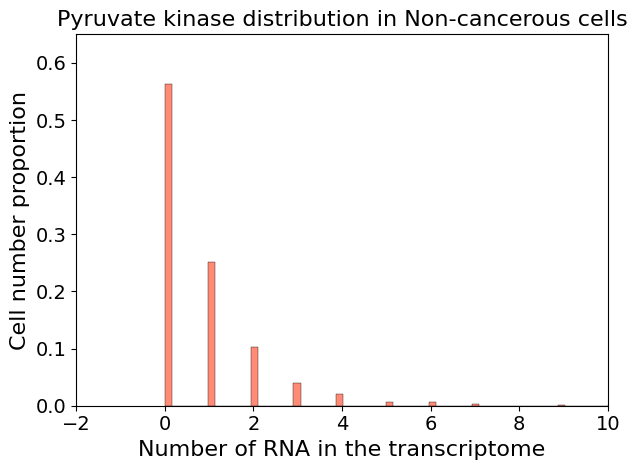

In [7]:
## For PYK
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['PYK'], kde=False, color='tomato',stat='probability')
plt.title('Pyruvate kinase distribution in Non-cancerous cells',fontsize=16)
plt.xlabel('Number of RNA in the transcriptome',fontsize=16)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.65)
plt.xlim(-2, 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('PYK_distribution/Pyruvate kinase in Healthy cells_2',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


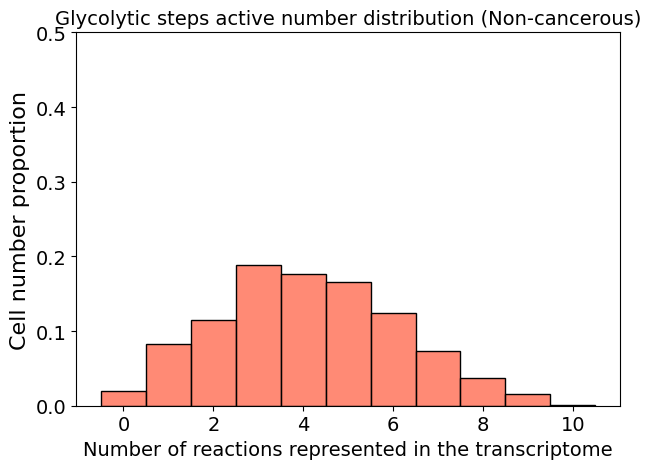

In [21]:
import seaborn as sns
from matplotlib import pyplot as plt
# Plotting the distribution with Seaborn
sns.histplot(df['Enzyme active number'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], 
             kde=False, color='tomato',stat='density')
plt.title('Glycolytic steps active number distribution (Non-cancerous)',fontsize=14)
plt.xlabel('Number of reactions represented in the transcriptome',fontsize=14)
plt.ylabel('Cell number proportion',fontsize=16)
plt.ylim(0, 0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 1])
# plt.show()
plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Healthy)',dpi=300)

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


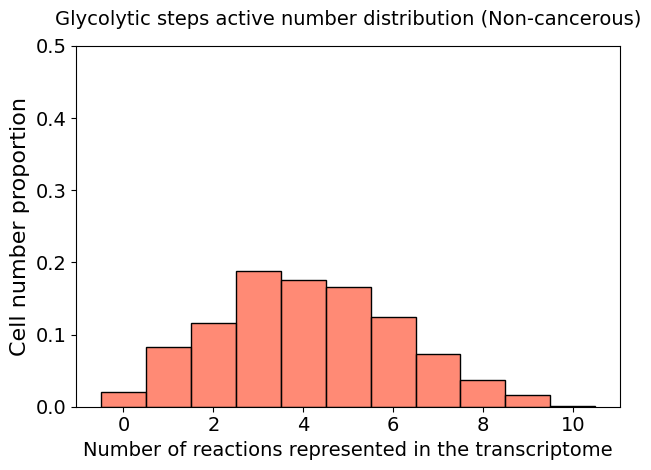

In [25]:
import seaborn as sns
from matplotlib import pyplot as plt

# ⭐ 建议先创建 figure
plt.figure()

# Plot
sns.histplot(
    df['Enzyme active number'],
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5],
    kde=False,
    color='tomato',
    stat='density'
)

# Labels
plt.title(
    'Glycolytic steps active number distribution (Non-cancerous)',
    fontsize=14,
    pad=15   # ⭐ 关键：标题下移一点
)

plt.xlabel('Number of reactions represented in the transcriptome', fontsize=14)
plt.ylabel('Cell number proportion', fontsize=16)

plt.ylim(0, 0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# ⭐ 给标题预留空间
plt.tight_layout()

# ⭐ 保存时避免裁剪
plt.savefig(
    'Enzyme_number_with_activity_distribution_in_glycolysis_Healthy.png',
    dpi=300,
    bbox_inches='tight'
)

# plt.show()
plt.savefig('Enzyme_number_with_activity_distribution_in_glycolysis(Healthy1)',dpi=300)

In [106]:
cumulative_counts = df.eq(0).sum()
cumulative_counts

HXK      1628
GPI      1687
PFK      1593
ALD       699
TPI1      955
GAPDH     278
PGK       972
PGAM     1175
ENO       911
PYK      1050
dtype: int64

In [107]:
# Count the number of rows with no 0 values
no_zero_rows = df[df.eq(0).sum(axis=1) == 0]

# Get the count of such rows
count_no_zero_rows = len(no_zero_rows)

print("Number of Rows with No 0 Values:", count_no_zero_rows)

Number of Rows with No 0 Values: 3


# Combining three together

In [10]:
file_path = 'Glycolysis_Pathway_activity_combining_four.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet6')
df = df.set_index('Reaction_id')
df

,Huh1,Huh7,Patient,Non-cancerous
Reaction_id,,,,
HXK,0.387025,0.122478,0.053492,0.126141
GPI,0.790828,0.385687,0.111441,0.094471
PFK,0.473154,0.553314,0.172363,0.144928
ALD,0.989933,0.992795,0.518574,0.624799
TPI1,0.998881,0.999039,0.570579,0.487386
GAPDH,1.000000,1.000000,0.864785,0.850778
PGK,0.894855,0.861191,0.421991,0.478261
PGAM,0.930649,0.961095,0.313522,0.369297
ENO,0.994407,0.997598,0.508172,0.511004


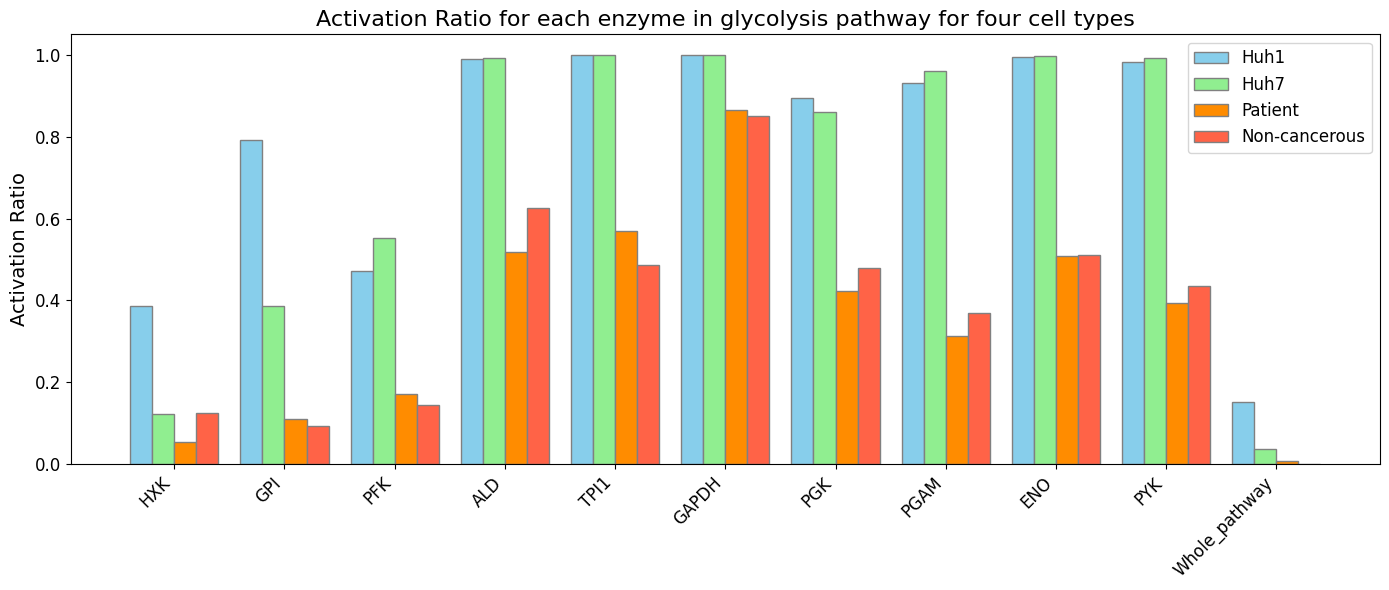

In [11]:
colors = ['skyblue', 'lightgreen', 'darkorange', 'tomato']
barWidth = 0.2
r = np.arange(len(df.index))
plt.figure(figsize=(14, 6))
for i, col in enumerate(df.columns):
    plt.bar(r + i * barWidth, df[col], width=barWidth, edgecolor='grey', label=col, color=colors[i % len(colors)])

# plt.xlabel('Enzyme name and whole pathway', fontsize=14)
plt.ylabel('Activation Ratio', fontsize=14)  # Change the font size here
plt.title('Activation Ratio for each enzyme in glycolysis pathway for four cell types', fontsize=16)
plt.xticks(r + barWidth * 1.5, df.index, rotation=45, ha='right',fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.show()
plt.savefig('Enzyme_activity_ratio_in_glycolysis(four_cells_together)',dpi=300)

## Activity comparision

In [13]:
file_path = 'Glycolysis_Pathway_activity_for_four_cell_types.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet10')
df = df.set_index('Reaction_id')
df

,Huh1,Huh7,Patient,Non-cancerous
Reaction_id,,,,
HXK,0.5459,0.1383,0.0624,0.1439
GPI,1.7875,0.5538,0.1516,0.1004
PFK,0.6902,0.9347,0.2600,0.1653
ALD,9.3568,13.4313,1.4666,1.3655
TPI1,16.2025,26.8814,2.4339,0.8830
GAPDH,58.6465,70.6302,9.2407,3.8792
PGK,3.6130,4.3554,1.1040,0.7837
PGAM,4.0895,6.7022,0.7786,0.5287
ENO,17.9553,19.9280,1.8559,0.9404


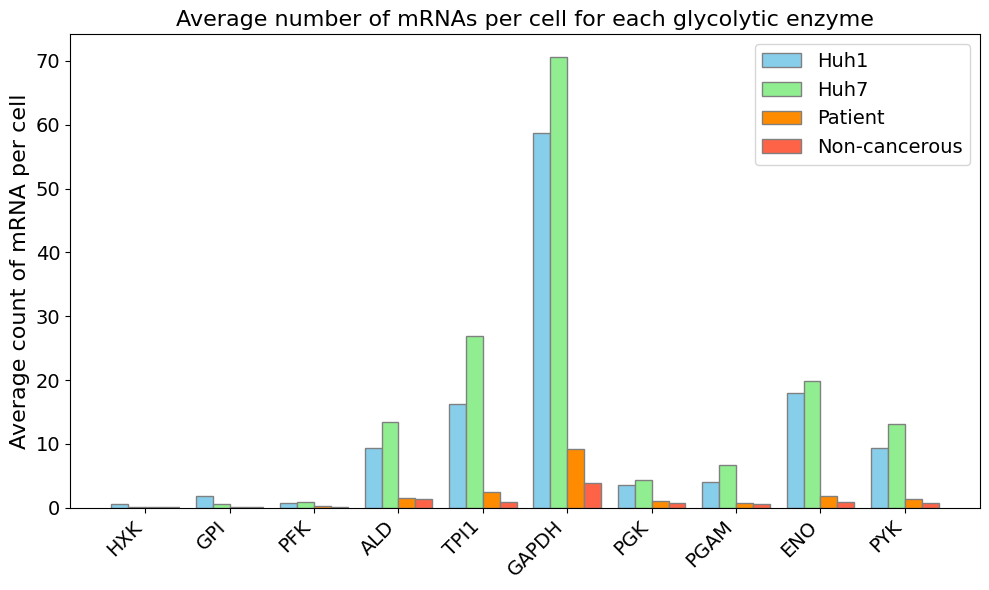

In [14]:
colors = ['skyblue', 'lightgreen', 'darkorange', 'tomato']
barWidth = 0.2
r = np.arange(len(df.index))
plt.figure(figsize=(10, 6))
for i, col in enumerate(df.columns):
    plt.bar(r + i * barWidth, df[col], width=barWidth, edgecolor='grey', label=col, color=colors[i % len(colors)])

# plt.xlabel('Enzyme name and whole pathway', fontsize=14)
plt.ylabel('Average count of mRNA per cell', fontsize=16)  # Change the font size here
plt.title('Average number of mRNAs per cell for each glycolytic enzyme', fontsize=16)
plt.xticks(r + barWidth * 1.5, df.index, rotation=45, ha='right',fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig('Glycolysis_enzyme_expression_activity(four_cells_together)',dpi=300)